# Customer Churn Prediction & Customer Segmentation

## Objective

This project aims to:
- Predict telecom customer churn using Random Forest.
- Identify key factors influencing churn.
- Segment customers using K-Means Clustering.
- Generate business insights for customer retention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [3]:
df


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


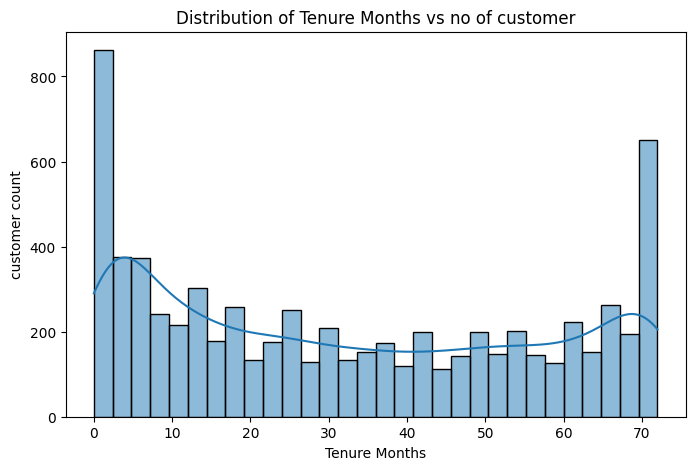

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.title('Distribution of Tenure Months vs no of customer')
plt.xlabel('Tenure Months')
plt.ylabel('customer count')
plt.show()

In [7]:
df['Tenure Months'].max()

72

In [8]:
df['Tenure Months'].min()

0

so width = 72-0/30 = 2.4

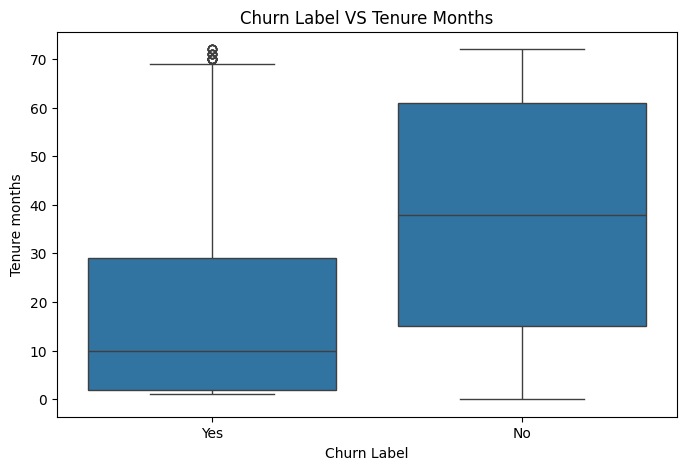

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label' , y = 'Tenure Months' , data=df)
plt.title('Churn Label VS Tenure Months')
plt.xlabel('Churn Label')
plt.ylabel('Tenure months')
plt.show()

In [10]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

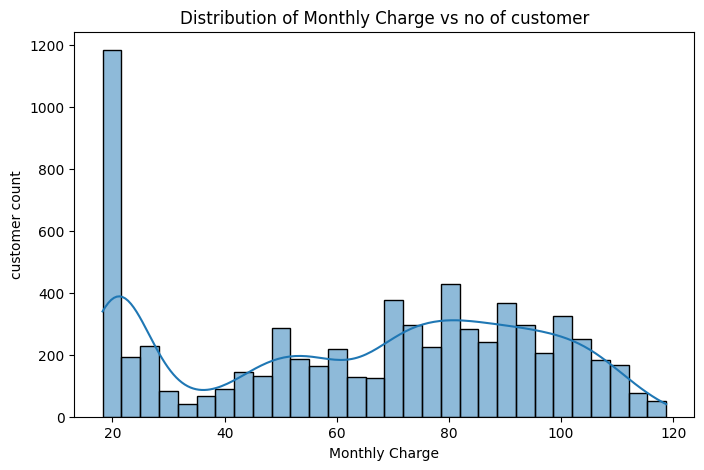

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.title('Distribution of Monthly Charge vs no of customer')
plt.xlabel('Monthly Charge')
plt.ylabel('customer count')
plt.show()

In [12]:
df['Monthly Charges'].max()

118.75

In [13]:
df['Monthly Charges'].min()

18.25

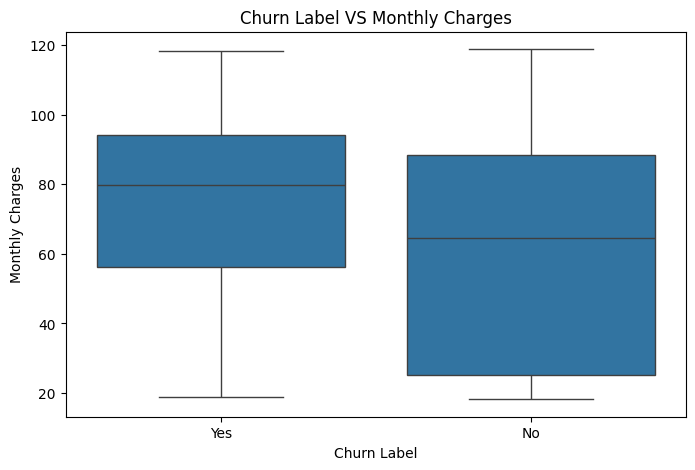

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label' , y = 'Monthly Charges' , data=df)
plt.title('Churn Label VS Monthly Charges')
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.show()

In [15]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [16]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [17]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [18]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [19]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [20]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


Text(0, 0.5, 'count')

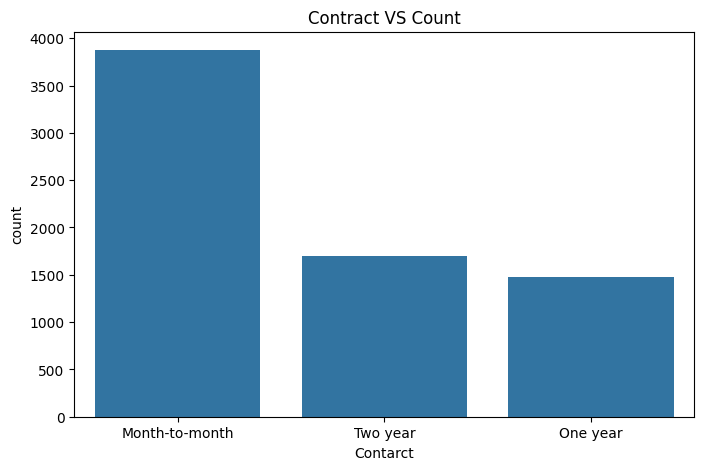

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', data=df)
plt.title('Contract VS Count')
plt.xlabel('Contarct')
plt.ylabel('count')

Text(0, 0.5, 'count')

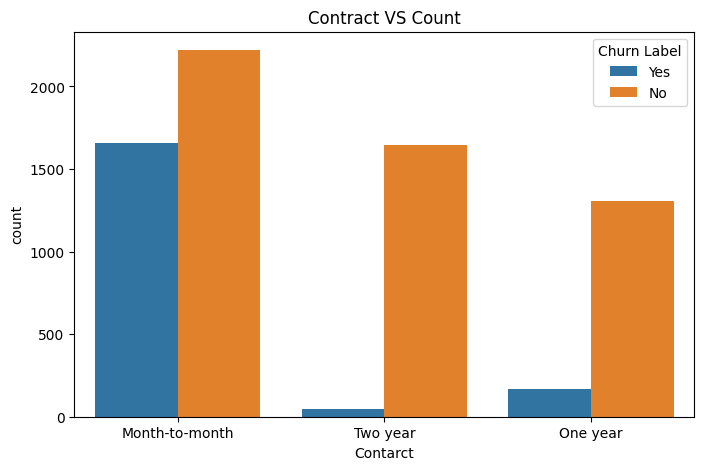

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.title('Contract VS Count')
plt.xlabel('Contarct')
plt.ylabel('count')

In [23]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

Text(0, 0.5, 'count')

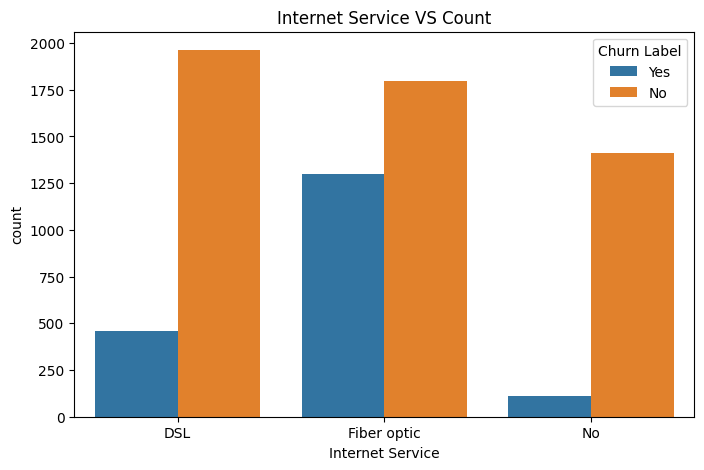

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service',hue='Churn Label', data=df)
plt.title('Internet Service VS Count')
plt.xlabel('Internet Service')
plt.ylabel('count')
#

In [25]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

Text(0, 0.5, 'count')

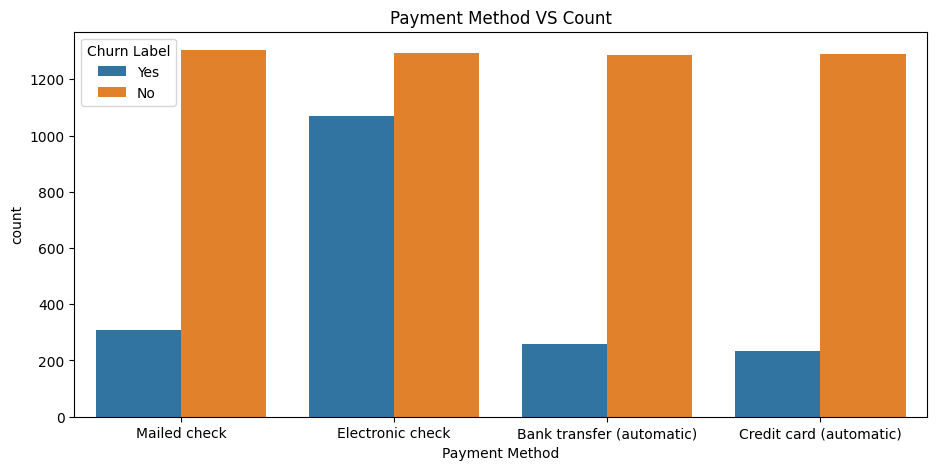

In [26]:
plt.figure(figsize=(11,5))
sns.countplot(x='Payment Method',hue='Churn Label', data=df)
plt.title('Payment Method VS Count')
plt.xlabel('Payment Method')
plt.ylabel('count')

In [27]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

Text(0, 0.5, 'count')

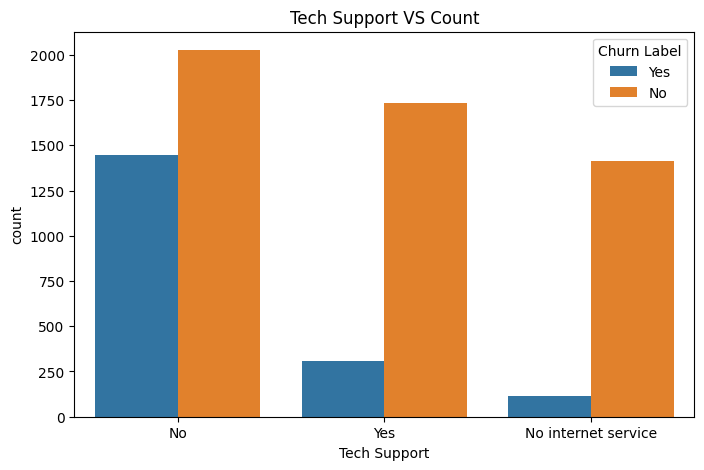

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support',hue='Churn Label', data=df)
plt.title('Tech Support VS Count')
plt.xlabel('Tech Support')
plt.ylabel('count')


In [29]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()

In [30]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [31]:
print(avg_tenure)

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64


In [32]:
numerical_cols = ['Tenure Months' ,'Monthly Charges','Churn Value' , 'Churn Score' , 'CLTV']
correlation_matrix = df[numerical_cols].corr()

In [33]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [34]:
Contract_Churn=pd.crosstab(df['Contract'],df['Churn Label'])

In [35]:
Contract_Churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [36]:
Contract_Churn=pd.crosstab(df['Contract'],df['Churn Label'], normalize='index')

In [37]:
Contract_Churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


### **DATA CLEANING**

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [39]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "City",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

In [40]:
df = df.drop(columns=drop_columns)

In [41]:
df.shape

(7043, 20)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

*First One-Hot Encoding*

In [43]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [44]:
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

Check Missing Values

In [45]:
df["Total Charges"].isnull().sum()

np.int64(0)

In [46]:
df['Total Charges'].dtype

dtype('float64')

In [47]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

In [48]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [49]:
df_encoded.shape

(7043, 31)

In [50]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [51]:
X = df_encoded.drop("Churn Value", axis=1)

In [52]:
Y = df_encoded["Churn Value"]

In [53]:
X.shape

(7043, 30)

In [54]:
Y.shape

(7043,)

In [55]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


**Train Test Split**

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.33,
    random_state=42
)

In [58]:
X_train.shape

(4718, 30)

In [59]:
X_test.shape

(2325, 30)

In [60]:
Y_test.shape

(2325,)

In [61]:
Y_train.shape


(4718,)

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)

In [64]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [65]:
y_pred=rf_model.predict(X_test)

In [66]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [67]:
from sklearn.metrics import accuracy_score

In [68]:
accuracy = accuracy_score(Y_test, y_pred)

In [69]:
accuracy

0.7909677419354839

In [70]:
from sklearn.metrics import confusion_matrix

In [71]:
cm=confusion_matrix(Y_test, y_pred)

In [72]:
cm

array([[1507,  177],
       [ 309,  332]])

In [73]:
from sklearn.metrics import classification_report

In [74]:
cr=classification_report(Y_test, y_pred)

In [75]:
cr

'              precision    recall  f1-score   support\n\n           0       0.83      0.89      0.86      1684\n           1       0.65      0.52      0.58       641\n\n    accuracy                           0.79      2325\n   macro avg       0.74      0.71      0.72      2325\nweighted avg       0.78      0.79      0.78      2325\n'

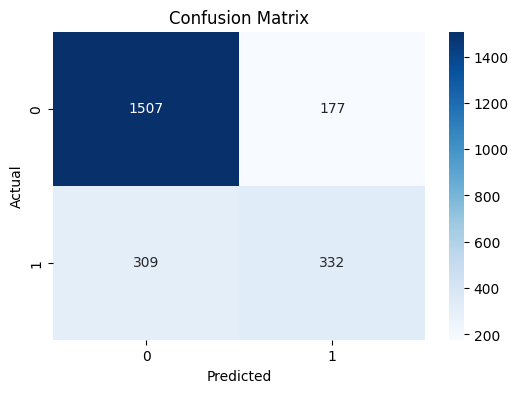

In [76]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**APPROACH 1 - HANDLE CLASS IMBALANCE**

In [77]:
rf_balanced=RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

In [78]:
rf_balanced.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [79]:
Y_pred_balanced=rf_balanced.predict(X_test)

In [80]:
accuracy_balanced=accuracy_score(Y_test, Y_pred_balanced)

In [81]:
accuracy_balanced

0.7944086021505377

In [82]:
cm_balanced=confusion_matrix(Y_test, Y_pred_balanced)

In [83]:
print(classification_report(Y_test, Y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1684
           1       0.67      0.51      0.58       641

    accuracy                           0.79      2325
   macro avg       0.75      0.71      0.72      2325
weighted avg       0.78      0.79      0.79      2325



**APPROACH 2: HYPERPARAMETER TUNING**

In [84]:
rf_tuned=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_tuned.fit(X_train,Y_train)
y_pred_tuned=rf_balanced.predict(X_test)

print (classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1684
           1       0.67      0.51      0.58       641

    accuracy                           0.79      2325
   macro avg       0.75      0.71      0.72      2325
weighted avg       0.78      0.79      0.79      2325



**FEATURE IMPORTANCE ANALYSIS**

In [85]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Features': X.columns,
    'Importance': rf_tuned.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Features,Importance
0,Tenure Months,0.178266
2,Total Charges,0.135340
1,Monthly Charges,0.099444
25,Contract_Two year,0.096022
6,Dependents_Yes,0.067672
10,Internet Service_Fiber optic,0.060323
28,Payment Method_Electronic check,0.045949
24,Contract_One year,0.038237
13,Online Security_Yes,0.030745
19,Tech Support_Yes,0.019759


In [86]:
feature_importance.nsmallest(10, 'Importance')

,Features,Importance
7,Phone Service_Yes,0.003756
8,Multiple Lines_No phone service,0.004044
29,Payment Method_Mailed check,0.008859
11,Internet Service_No,0.009851
14,Online Backup_No internet service,0.009889
17,Device Protection_Yes,0.010119
4,Senior Citizen_Yes,0.010191
21,Streaming TV_Yes,0.010925
20,Streaming TV_No internet service,0.011170
27,Payment Method_Credit card (automatic),0.011422


In [87]:
print(feature_importance.tail(15))

                                  Features  Importance
15                       Online Backup_Yes    0.012607
16   Device Protection_No internet service    0.011481
17                   Device Protection_Yes    0.010119
18        Tech Support_No internet service    0.012767
19                        Tech Support_Yes    0.019759
20        Streaming TV_No internet service    0.011170
21                        Streaming TV_Yes    0.010925
22    Streaming Movies_No internet service    0.013213
23                    Streaming Movies_Yes    0.012590
24                       Contract_One year    0.038237
25                       Contract_Two year    0.096022
26                   Paperless Billing_Yes    0.018876
27  Payment Method_Credit card (automatic)    0.011422
28         Payment Method_Electronic check    0.045949
29             Payment Method_Mailed check    0.008859


In [88]:
X_selected = X.drop(
    ['Phone Service_Yes',
     'Multiple Lines_No phone service'],
    axis=1
)

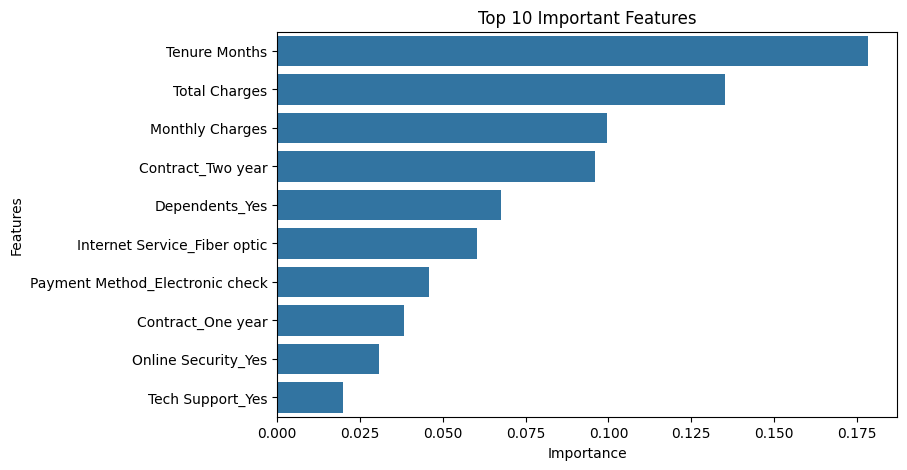

In [89]:
top10 = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Features',
    data=top10
)

plt.title("Top 10 Important Features")
plt.show()

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [91]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected,
    Y,
    test_size=0.2,
    random_state=42
)

In [92]:
rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_selected.fit(X_train_sel, Y_train_sel)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [93]:
y_pred_selected = rf_selected.predict(X_test_sel)

print(classification_report(Y_test_sel, y_pred_selected))


              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [94]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

In [95]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]

results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:

        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        rf.fit(X_train, Y_train)

        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        precision = precision_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)

        results.append({
            'Trees': n_trees,
            'Depth': depth,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1
        })

result_df = pd.DataFrame(results)

result_df = result_df.sort_values(
    by=['Recall', 'Accuracy'],
    ascending=False
)

print(result_df.head(20))

    Trees  Depth  Accuracy    Recall  Precision  F1 Score
12    400      5  0.752258  0.822153   0.532861  0.646626
8     300      5  0.751398  0.822153   0.531786  0.645833
16    500      5  0.751828  0.820593   0.532389  0.645795
4     200      5  0.752688  0.814353   0.533742  0.644842
0     100      5  0.750968  0.808112   0.531828  0.641486
13    400     10  0.782366  0.755070   0.581032  0.656716
17    500     10  0.782796  0.753510   0.581928  0.656696
9     300     10  0.782366  0.753510   0.581227  0.656250
5     200     10  0.784516  0.751950   0.584951  0.658020
1     100     10  0.781505  0.747270   0.580606  0.653479
18    500     15  0.799140  0.625585   0.638535  0.631994
10    300     15  0.797849  0.620905   0.636800  0.628752
14    400     15  0.797849  0.620905   0.636800  0.628752
2     100     15  0.794839  0.616225   0.630990  0.623520
6     200     15  0.794409  0.608424   0.632091  0.620032
19    500     20  0.796559  0.536661   0.661538  0.592593
15    400     

In [96]:
from sklearn.model_selection import cross_val_score

In [97]:
final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

Accuracy Cross Validation

In [98]:
cv_accuracy = cross_val_score(
    final_rf,
    X,
    Y,
    cv=5,
    scoring='accuracy'
)

print(cv_accuracy)
print("Mean Accuracy:", cv_accuracy.mean())

[0.76792051 0.79985806 0.75869411 0.78622159 0.78622159]
Mean Accuracy: 0.7797831714949351


Recall Cross Validation

In [99]:
cv_recall = cross_val_score(
    final_rf,
    X,
    Y,
    cv=5,
    scoring='recall'
)

print(cv_recall)
print("Mean Recall:", cv_recall.mean())

[0.70320856 0.77005348 0.72994652 0.73796791 0.71313673]
Mean Recall: 0.7308626399621511


OPTIONAL


In [100]:
from sklearn.metrics import roc_curve, roc_auc_score

In [101]:
import matplotlib.pyplot as plt

In [102]:
y_prob1=rf_tuned.predict_proba(X_test)

In [103]:
churn_prob= y_prob1[:,1]

In [104]:
y_prob1=rf_tuned.predict_proba(X_test)

In [105]:
y_prob=rf_tuned.predict_proba(X)

In [106]:
churn_probability= y_prob[:,1]

In [107]:
fpr,tpr,threshold=roc_curve(Y_test,churn_prob)
auc_score=roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.8582293291731671


**CUSTOMER SEGMENTATION**

In [108]:
segmentation_data=pd.DataFrame({
  'Tenure Months':X['Tenure Months'],
  'Monthly Charges':X['Monthly Charges'],
  'Total Charges':X['Total Charges'],
  'Churn Probability':churn_probability})

In [109]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.707739
1,2,70.70,151.65,0.824012
2,8,99.65,820.50,0.821192
3,28,104.80,3046.05,0.599516
4,49,103.70,5036.30,0.515224
...,...,...,...,...
7038,72,21.15,1419.40,0.003854
7039,24,84.80,1990.50,0.062637
7040,72,103.20,7362.90,0.056403
7041,11,29.60,346.45,0.452511


Implementation of K mean

In [110]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)


In [111]:
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.95967407  1.13777561]
 [-1.23672422  0.19736523 -0.9404697   1.51793302]
 [-0.99240204  1.1595457  -0.64518597  1.50871412]
 [-0.17799476  1.33071079  0.33734927  0.78393692]
 [ 0.67713287  1.29415125  1.21600434  0.5083412 ]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

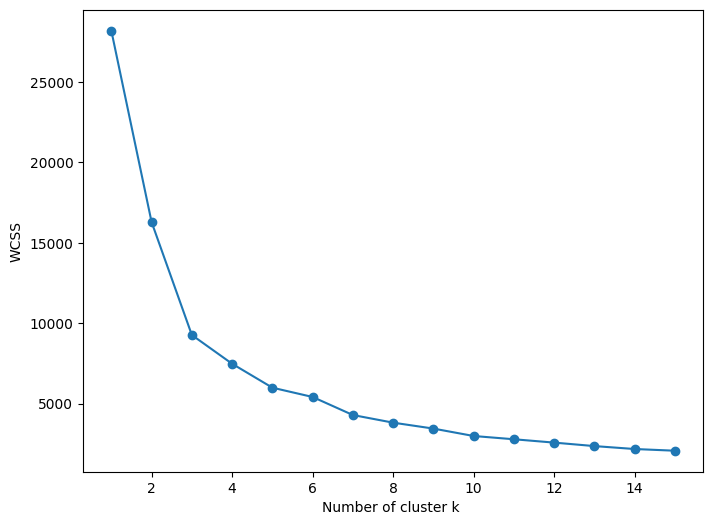

In [112]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.show()

In [113]:
kmeans=KMeans(n_clusters=3, random_state=42)

In [114]:
clusters=kmeans.fit_predict(scaled_data)

In [115]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.707739
1,2,70.70,151.65,0.824012
2,8,99.65,820.50,0.821192
3,28,104.80,3046.05,0.599516
4,49,103.70,5036.30,0.515224
...,...,...,...,...
7038,72,21.15,1419.40,0.003854
7039,24,84.80,1990.50,0.062637
7040,72,103.20,7362.90,0.056403
7041,11,29.60,346.45,0.452511


In [116]:
segmentation_data['Clusters']=clusters

In [117]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Clusters
0,2,53.85,108.15,0.707739,1
1,2,70.70,151.65,0.824012,1
2,8,99.65,820.50,0.821192,1
3,28,104.80,3046.05,0.599516,1
4,49,103.70,5036.30,0.515224,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003854,0
7039,24,84.80,1990.50,0.062637,0
7040,72,103.20,7362.90,0.056403,2
7041,11,29.60,346.45,0.452511,0


In [118]:
cluster_summary=segmentation_data.groupby('Clusters').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Clusters,,,,
0,31.628415,33.473476,1057.188346,0.119591
1,11.072892,72.490445,898.480477,0.692089
2,58.627940,90.546778,5303.925870,0.231731


In [119]:
cluster_names={
0:'Budget Loyal Customers',
1:'High Risk New Customers',
2:'Loyal Premium Customers'
}

In [120]:
segmentation_data['Cluster Segment']=segmentation_data['Clusters'].map(cluster_names)

In [121]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Clusters,Cluster Segment
0,2,53.85,108.15,0.707739,1,High Risk New Customers
1,2,70.70,151.65,0.824012,1,High Risk New Customers
2,8,99.65,820.50,0.821192,1,High Risk New Customers
3,28,104.80,3046.05,0.599516,1,High Risk New Customers
4,49,103.70,5036.30,0.515224,2,Loyal Premium Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003854,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.062637,0,Budget Loyal Customers
7040,72,103.20,7362.90,0.056403,2,Loyal Premium Customers
7041,11,29.60,346.45,0.452511,0,Budget Loyal Customers


In [122]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: title={'center': 'Customer Segmentation based on Monthly Charges'}, xlabel='Monthly Charges', ylabel='Churn Probability'>

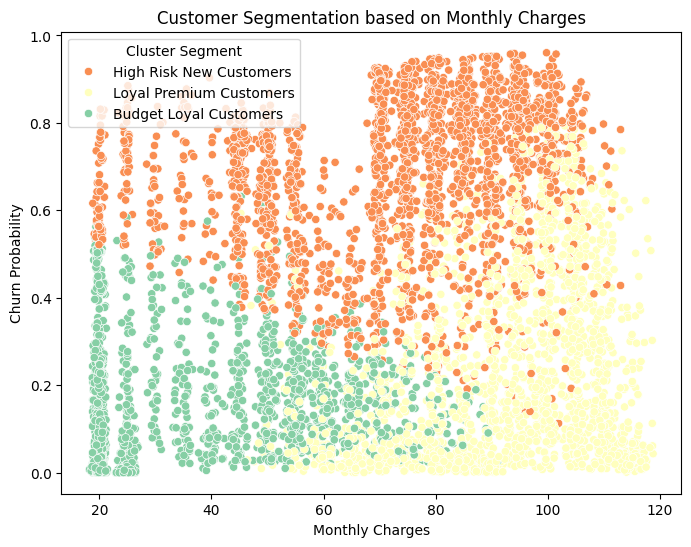

In [123]:
plt.figure(figsize=(8, 6))
plt.title("Customer Segmentation based on Monthly Charges")
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: title={'center': 'Customer Segmentation based on Tenure Months'}, xlabel='Tenure Months', ylabel='Churn Probability'>

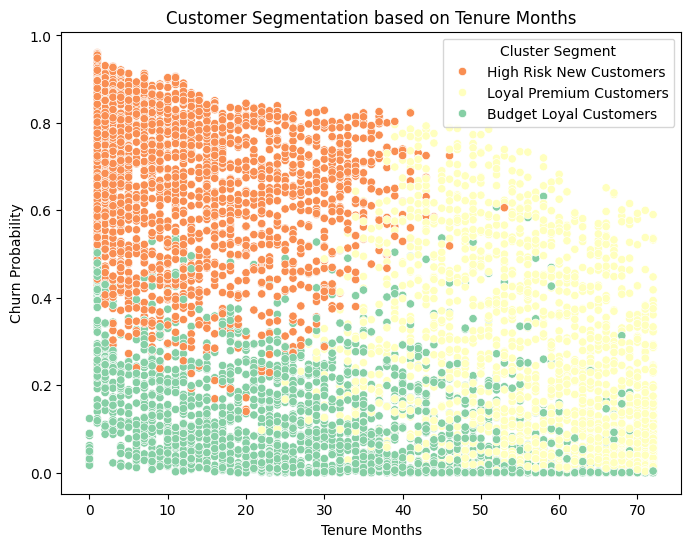

In [124]:
plt.figure(figsize=(8, 6))
plt.title("Customer Segmentation based on Tenure Months")
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: title={'center': 'Customer Segmentation based on Total Charges'}, xlabel='Total Charges', ylabel='Churn Probability'>

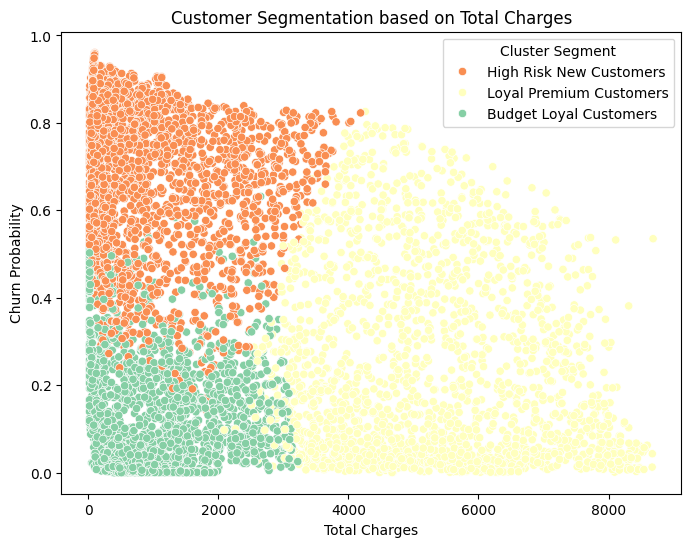

In [125]:
plt.figure(figsize=(8, 6))
plt.title("Customer Segmentation based on Total Charges")
sns.scatterplot(x='Total Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

### ROC Curve + AUC Score

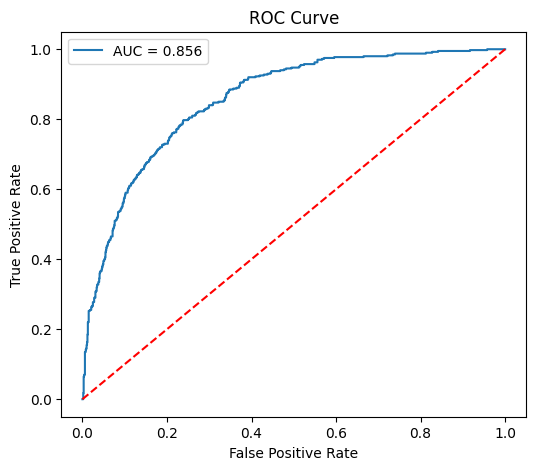

In [126]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_selected.predict_proba(X_test_sel)[:,1]

fpr, tpr, thresholds = roc_curve(
    Y_test_sel,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Business Insights


*   Customers with lower tenure are more likely to churn.
*   Monthly charges significantly influence churn probability.
*   Long-term contract customers show lower churn rates.
*   Loyal Premium Customers contribute high revenue and should be retained using reward programs.
*   High Risk New Customers need onboarding and retention offers.








# Conclusion

- Random Forest successfully predicted customer churn.
- Feature Importance Analysis identified major churn drivers.
- K-Means Clustering segmented customers into meaningful groups.
- Business recommendations were generated for customer retention and targeted marketing.